# RSSM — Recurrent State Space Model Visual Experiments

> **Goal:** Build intuition for why RSSM separates recurrent memory from stochastic state, and why Dreamer must train and evaluate the prior used for imagination.

## What we will explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Deterministic memory path** | Why not pass long-term memory only through stochastic samples? |
| 2 | **Filtering versus imagination** | What changes when observation correction is removed? |
| 3 | **Prior-posterior gap** | Where does model surprise appear, and how does it predict rollout drift? |
| 4 | **KL balancing and free bits** | Why separate dynamics learning from representation regularization? |
| 5 | **Model exploitation** | How can an actor exploit optimistic imagined returns? |

**Linked theory:** [RSSM — Recurrent State Space Model](../research/04-rssm-recurrent-state-space-model.md)

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})

def gaussian_kl(mean_q, std_q, mean_p, std_p):
    return np.log(std_p / std_q) + (std_q**2 + (mean_q - mean_p)**2) / (2.0 * std_p**2) - 0.5

---
## Experiment 1: A stable path for delayed information

**Question:** Why is a deterministic recurrent state useful when a cue must survive many stochastic transitions?

Each episode reveals a binary cue only at the first step. We compare a stochastic-only state that must repeatedly resample the cue with an RSSM-like split where a deterministic state carries memory and a stochastic state handles local innovation.

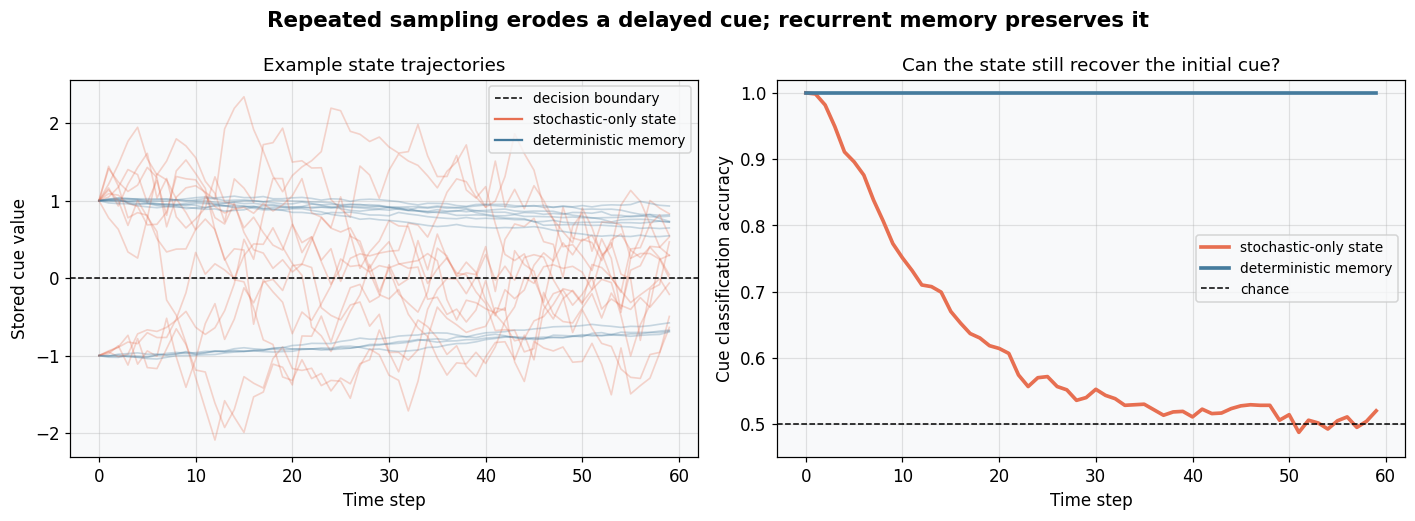

In [2]:
np.random.seed(1)
episode_count = 1200
horizon = 60
cues = np.random.choice([-1.0, 1.0], size=episode_count)

stochastic_only = np.zeros((horizon, episode_count))
deterministic_memory = np.zeros((horizon, episode_count))
stochastic_only[0] = cues
deterministic_memory[0] = cues

for step in range(1, horizon):
    stochastic_only[step] = 0.92 * stochastic_only[step - 1] + 0.28 * np.random.randn(episode_count)
    deterministic_memory[step] = 0.995 * deterministic_memory[step - 1] + 0.015 * np.random.randn(episode_count)

stochastic_accuracy = np.mean(np.sign(stochastic_only) == cues, axis=1)
memory_accuracy = np.mean(np.sign(deterministic_memory) == cues, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle('Repeated sampling erodes a delayed cue; recurrent memory preserves it', fontsize=14, fontweight='bold')

for episode in range(12):
    axes[0].plot(stochastic_only[:, episode], color='#e76f51', alpha=0.28, linewidth=1.1)
    axes[0].plot(deterministic_memory[:, episode], color='#457b9d', alpha=0.28, linewidth=1.1)
axes[0].axhline(0.0, color='black', linewidth=1.0, linestyle='--', label='decision boundary')
axes[0].plot([], [], color='#e76f51', label='stochastic-only state')
axes[0].plot([], [], color='#457b9d', label='deterministic memory')
axes[0].set_title('Example state trajectories')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Stored cue value')
axes[0].legend(fontsize=9)

axes[1].plot(stochastic_accuracy, color='#e76f51', linewidth=2.4, label='stochastic-only state')
axes[1].plot(memory_accuracy, color='#457b9d', linewidth=2.4, label='deterministic memory')
axes[1].axhline(0.5, color='black', linewidth=1.0, linestyle='--', label='chance')
axes[1].set_title('Can the state still recover the initial cue?')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Cue classification accuracy')
axes[1].set_ylim(0.45, 1.02)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** The stochastic-only trajectories gradually cross the decision boundary, so cue accuracy decays toward chance. The deterministic path remains close to its initial sign and preserves nearly all cue information.
2. **Why it looks this way:** Sampling noise is injected again at every stochastic transition. A recurrent deterministic path can transport information without repeatedly corrupting it, while the stochastic component remains available for unpredictable events.
3. **Key takeaway:** The RSSM split is an optimization bias for stable memory plus uncertainty, not a claim that the world literally decomposes into deterministic and random variables.

---
## Experiment 2: Filtering versus prior-only imagination

**Question:** What happens when an RSSM stops receiving observations and must roll out only from its prior?

A synthetic system receives noisy observations and an unmodeled disturbance. Filtering uses each observation to correct the prior state. Imagination starts from the same context but receives no future correction.

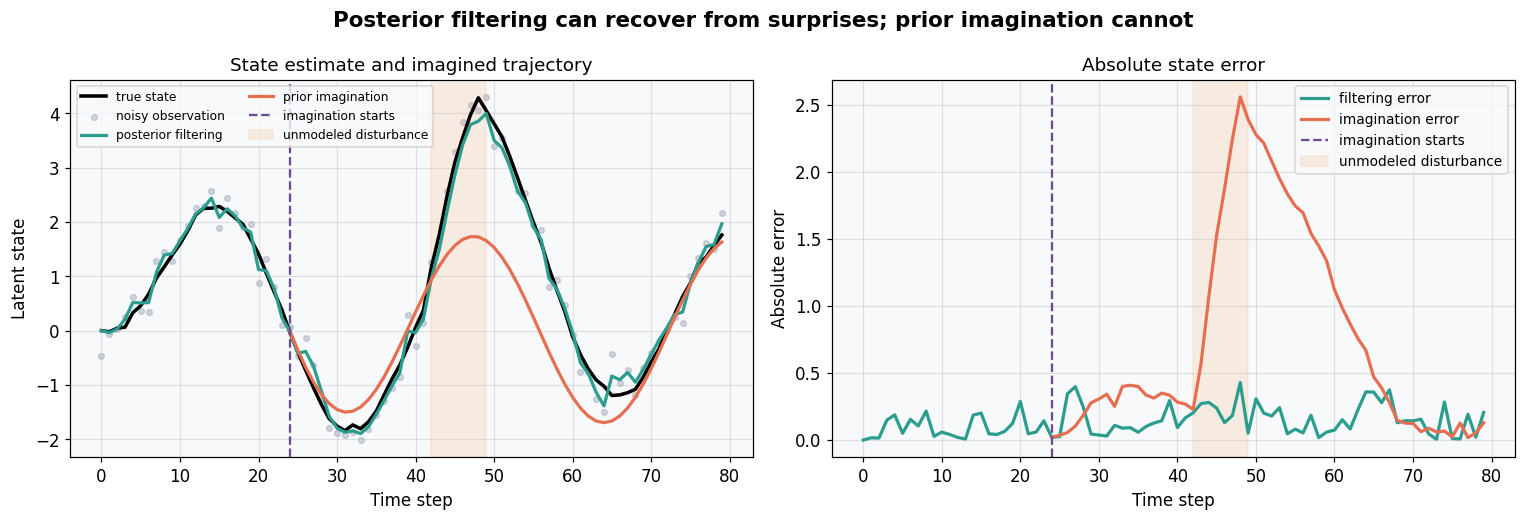

In [3]:
np.random.seed(2)
steps = 80
context_end = 24
time = np.arange(steps)
actions = 0.35 * np.sin(0.19 * time)
true_state = np.zeros(steps)

for step in range(1, steps):
    disturbance = 0.42 if 42 <= step < 49 else 0.0
    true_state[step] = 0.93 * true_state[step - 1] + actions[step - 1] + disturbance + 0.05 * np.random.randn()

observations = true_state + 0.23 * np.random.randn(steps)
filtered_state = np.zeros(steps)
prior_before_correction = np.zeros(steps)
kalman_like_gain = 0.58

for step in range(1, steps):
    prior_before_correction[step] = 0.90 * filtered_state[step - 1] + actions[step - 1]
    filtered_state[step] = prior_before_correction[step] + kalman_like_gain * (observations[step] - prior_before_correction[step])

imagined_state = np.full(steps, np.nan)
imagined_state[context_end] = filtered_state[context_end]
for step in range(context_end + 1, steps):
    imagined_state[step] = 0.90 * imagined_state[step - 1] + actions[step - 1]

filtered_error = np.abs(filtered_state - true_state)
imagined_error = np.abs(imagined_state - true_state)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
fig.suptitle('Posterior filtering can recover from surprises; prior imagination cannot', fontsize=14, fontweight='bold')

axes[0].plot(time, true_state, color='black', linewidth=2.3, label='true state')
axes[0].scatter(time, observations, color='#8d99ae', alpha=0.38, s=14, label='noisy observation')
axes[0].plot(time, filtered_state, color='#2a9d8f', linewidth=2.1, label='posterior filtering')
axes[0].plot(time, imagined_state, color='#e76f51', linewidth=2.1, label='prior imagination')
axes[0].axvline(context_end, color='#6a4c93', linestyle='--', linewidth=1.5, label='imagination starts')
axes[0].axvspan(42, 49, color='#f4a261', alpha=0.16, label='unmodeled disturbance')
axes[0].set_title('State estimate and imagined trajectory')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Latent state')
axes[0].legend(fontsize=8, ncol=2)

axes[1].plot(time, filtered_error, color='#2a9d8f', linewidth=2.1, label='filtering error')
axes[1].plot(time, imagined_error, color='#e76f51', linewidth=2.1, label='imagination error')
axes[1].axvline(context_end, color='#6a4c93', linestyle='--', linewidth=1.5, label='imagination starts')
axes[1].axvspan(42, 49, color='#f4a261', alpha=0.16, label='unmodeled disturbance')
axes[1].set_title('Absolute state error')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('Absolute error')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** Filtering tracks the real state despite noisy measurements and rapidly corrects after the disturbance. Prior imagination initially follows the system but drifts once reality contains information absent from the learned transition.
2. **Why it looks this way:** The posterior can use the current observation; the prior can use only recurrent history and actions. Once imagination begins, every prediction becomes input to the next prediction and no sensor update can repair the trajectory.
3. **Key takeaway:** Good posterior reconstruction is not evidence of good imagination. RSSM evaluation must explicitly switch from `observe` to prior-only `imagine`.

---
## Experiment 3: The prior-posterior gap is a surprise signal

**Question:** Can the KL divergence between posterior and prior identify events that the dynamics model failed to predict?

We interpret the pre-correction estimate as a Gaussian prior and the corrected estimate as a narrower Gaussian posterior. Their KL divergence measures how much information the new observation contributes beyond the dynamics prediction.

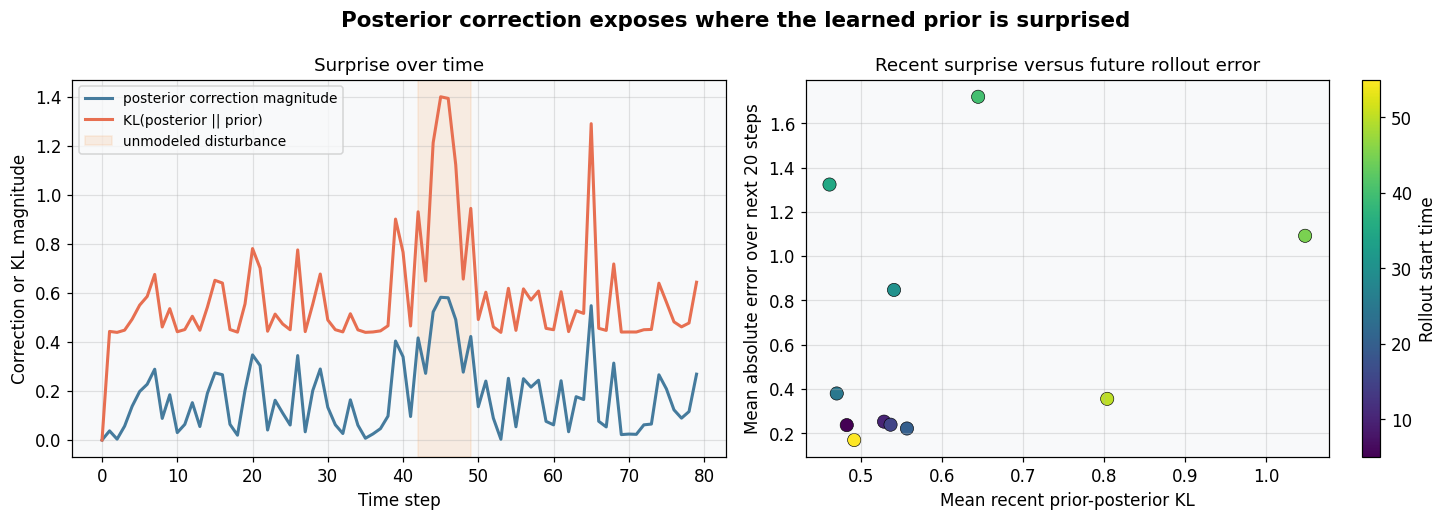

In [4]:
np.random.seed(3)
prior_std = np.full(steps, 0.42)
posterior_std = np.full(steps, 0.18)
posterior_std[0] = prior_std[0]
kl_by_step = gaussian_kl(filtered_state, posterior_std, prior_before_correction, prior_std)
correction_size = np.abs(filtered_state - prior_before_correction)

rollout_starts = np.arange(5, 56, 5)
rollout_horizon = 20
future_error = []
context_kl = []
for start in rollout_starts:
    forecast = filtered_state[start]
    forecast_values = []
    for step in range(start + 1, min(start + rollout_horizon + 1, steps)):
        forecast = 0.90 * forecast + actions[step - 1]
        forecast_values.append(forecast)
    target = true_state[start + 1:start + 1 + len(forecast_values)]
    future_error.append(np.mean(np.abs(np.asarray(forecast_values) - target)))
    context_kl.append(np.mean(kl_by_step[max(0, start - 3):start + 1]))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
fig.suptitle('Posterior correction exposes where the learned prior is surprised', fontsize=14, fontweight='bold')

axes[0].plot(time, correction_size, color='#457b9d', linewidth=2.0, label='posterior correction magnitude')
axes[0].plot(time, kl_by_step, color='#e76f51', linewidth=2.0, label='KL(posterior || prior)')
axes[0].axvspan(42, 49, color='#f4a261', alpha=0.16, label='unmodeled disturbance')
axes[0].set_title('Surprise over time')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Correction or KL magnitude')
axes[0].legend(fontsize=9)

scatter = axes[1].scatter(context_kl, future_error, c=rollout_starts, cmap='viridis', s=75, edgecolor='black', linewidth=0.4)
axes[1].set_title('Recent surprise versus future rollout error')
axes[1].set_xlabel('Mean recent prior-posterior KL')
axes[1].set_ylabel('Mean absolute error over next 20 steps')
colorbar = fig.colorbar(scatter, ax=axes[1])
colorbar.set_label('Rollout start time')

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** Posterior corrections and KL rise around observations that disagree with the transition prior. Rollouts launched near high-surprise contexts tend to have larger future error.
2. **Why it looks this way:** A large KL means the observation-informed state moved far from what recurrent dynamics predicted. That mismatch often marks missing dynamics, a regime change, or state information the prior cannot carry.
3. **Key takeaway:** Log KL, prior entropy, posterior entropy, and correction magnitude separately. A single aggregate world-model loss hides the locations where imagination becomes unreliable.

---
## Experiment 4: KL balancing protects the representation while training the prior

**Question:** Why use stop-gradient, dynamics-heavy KL balancing, and free bits instead of one symmetric pressure between prior and posterior?

This scalar optimization toy gives the posterior a reconstruction target at 2.0 while the prior begins at 0. A standard KL can reduce mismatch partly by pulling the informative posterior backward. Dynamics-heavy balancing directs more learning pressure into the prior, and free bits stop regularization once the mismatch is small.

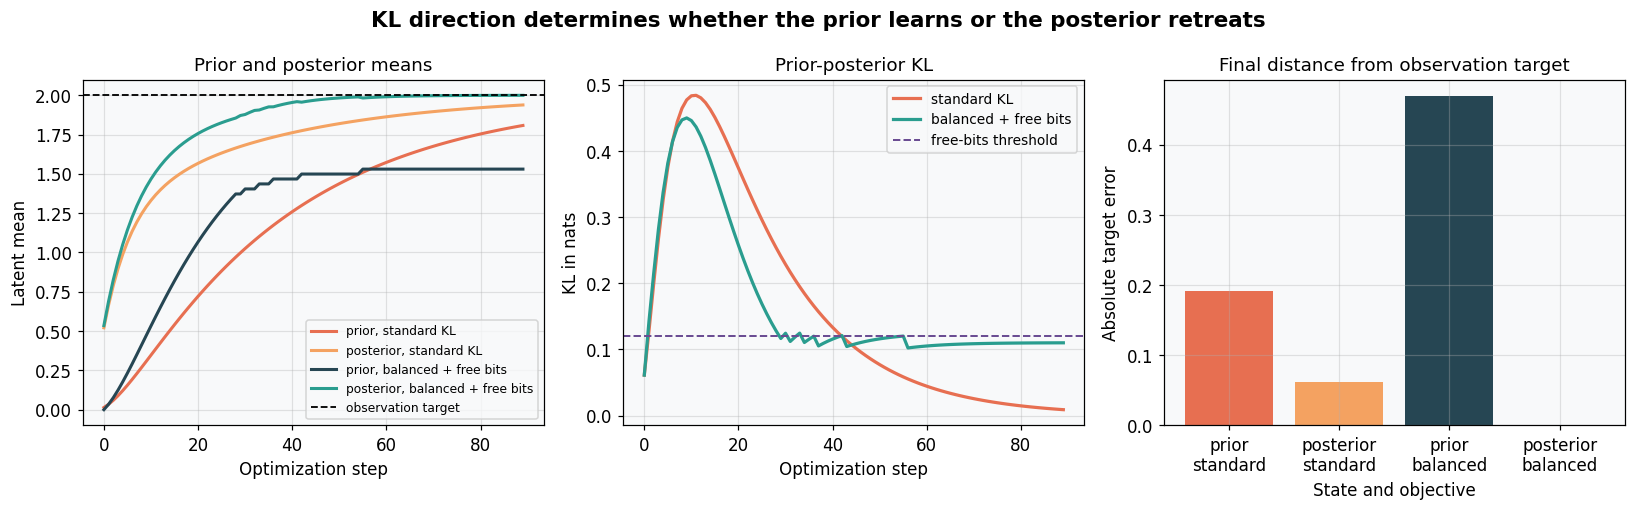

In [5]:
np.random.seed(4)

def optimize_scalar_rssm(alpha, free_nats, iterations=90, learning_rate=0.08):
    prior_mean = 0.0
    posterior_mean = 0.35
    target = 2.0
    history = {'prior': [], 'posterior': [], 'kl': [], 'reconstruction': []}

    for _ in range(iterations):
        kl_value = 0.5 * (posterior_mean - prior_mean) ** 2
        regularization_active = float(kl_value > free_nats)
        prior_gradient = alpha * (prior_mean - posterior_mean) * regularization_active
        posterior_gradient = (
            1.4 * (posterior_mean - target)
            + (1.0 - alpha) * (posterior_mean - prior_mean) * regularization_active
        )
        prior_mean -= learning_rate * prior_gradient
        posterior_mean -= learning_rate * posterior_gradient
        history['prior'].append(prior_mean)
        history['posterior'].append(posterior_mean)
        history['kl'].append(kl_value)
        history['reconstruction'].append((posterior_mean - target) ** 2)

    return {key: np.asarray(value) for key, value in history.items()}

standard_kl = optimize_scalar_rssm(alpha=0.5, free_nats=0.0)
balanced_kl = optimize_scalar_rssm(alpha=0.8, free_nats=0.12)
iterations = np.arange(len(standard_kl['prior']))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7))
fig.suptitle('KL direction determines whether the prior learns or the posterior retreats', fontsize=14, fontweight='bold')

axes[0].plot(iterations, standard_kl['prior'], color='#e76f51', linewidth=2.0, label='prior, standard KL')
axes[0].plot(iterations, standard_kl['posterior'], color='#f4a261', linewidth=2.0, label='posterior, standard KL')
axes[0].plot(iterations, balanced_kl['prior'], color='#264653', linewidth=2.0, label='prior, balanced + free bits')
axes[0].plot(iterations, balanced_kl['posterior'], color='#2a9d8f', linewidth=2.0, label='posterior, balanced + free bits')
axes[0].axhline(2.0, color='black', linestyle='--', linewidth=1.2, label='observation target')
axes[0].set_title('Prior and posterior means')
axes[0].set_xlabel('Optimization step')
axes[0].set_ylabel('Latent mean')
axes[0].legend(fontsize=8)

axes[1].plot(iterations, standard_kl['kl'], color='#e76f51', linewidth=2.1, label='standard KL')
axes[1].plot(iterations, balanced_kl['kl'], color='#2a9d8f', linewidth=2.1, label='balanced + free bits')
axes[1].axhline(0.12, color='#6a4c93', linestyle='--', linewidth=1.3, label='free-bits threshold')
axes[1].set_title('Prior-posterior KL')
axes[1].set_xlabel('Optimization step')
axes[1].set_ylabel('KL in nats')
axes[1].legend(fontsize=9)

final_errors = [
    abs(standard_kl['prior'][-1] - 2.0),
    abs(standard_kl['posterior'][-1] - 2.0),
    abs(balanced_kl['prior'][-1] - 2.0),
    abs(balanced_kl['posterior'][-1] - 2.0),
]
axes[2].bar(
    ['prior\nstandard', 'posterior\nstandard', 'prior\nbalanced', 'posterior\nbalanced'],
    final_errors,
    color=['#e76f51', '#f4a261', '#264653', '#2a9d8f'],
)
axes[2].set_title('Final distance from observation target')
axes[2].set_xlabel('State and objective')
axes[2].set_ylabel('Absolute target error')

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** Both objectives reduce KL, but dynamics-heavy balancing moves the prior toward the informative posterior more aggressively. The free-bits version stops spending gradient on a small residual mismatch, leaving the posterior close to its reconstruction target.
2. **Why it looks this way:** Stop-gradient separates two jobs: train the dynamics prior to match a fixed posterior target, and regularize the representation toward a fixed prior. Weighting the first job more heavily prevents KL reduction from being achieved mainly by deleting observation information.
3. **Key takeaway:** A low KL is ambiguous. It can mean a strong prior or a collapsed posterior, so RSSM diagnostics must inspect which side moved and whether prediction quality survived.

---
## Experiment 5: Optimistic imagination invites model exploitation

**Question:** Why can an actor trained inside an RSSM choose actions that look excellent in imagination but fail in the real environment?

The learned model underestimates the cost of aggressive actions outside the well-covered data region. We compare the action preferred by imagined reward with a simple uncertainty-penalized objective, then examine how their return error compounds with rollout horizon.

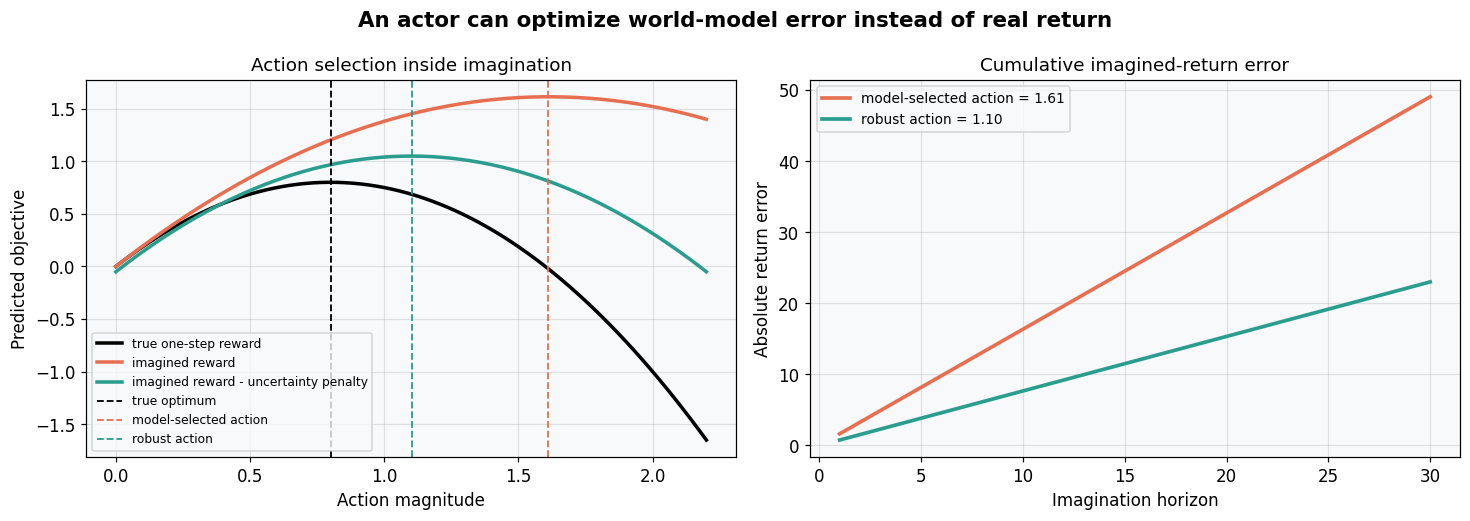

In [6]:
np.random.seed(5)
action_grid = np.linspace(0.0, 2.2, 300)
true_reward = 2.0 * action_grid - 1.25 * action_grid**2
imagined_reward = 2.0 * action_grid - 0.62 * action_grid**2
model_uncertainty = 0.06 + 0.34 * action_grid**2
robust_objective = imagined_reward - 0.85 * model_uncertainty

model_action = action_grid[np.argmax(imagined_reward)]
robust_action = action_grid[np.argmax(robust_objective)]
true_action = action_grid[np.argmax(true_reward)]
horizons = np.arange(1, 31)

def reward_at(action, curvature):
    return 2.0 * action - curvature * action**2

model_return_error = horizons * abs(reward_at(model_action, 0.62) - reward_at(model_action, 1.25))
robust_return_error = horizons * abs(reward_at(robust_action, 0.62) - reward_at(robust_action, 1.25))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
fig.suptitle('An actor can optimize world-model error instead of real return', fontsize=14, fontweight='bold')

axes[0].plot(action_grid, true_reward, color='black', linewidth=2.3, label='true one-step reward')
axes[0].plot(action_grid, imagined_reward, color='#e76f51', linewidth=2.3, label='imagined reward')
axes[0].plot(action_grid, robust_objective, color='#2a9d8f', linewidth=2.3, label='imagined reward - uncertainty penalty')
axes[0].axvline(true_action, color='black', linestyle='--', linewidth=1.2, label='true optimum')
axes[0].axvline(model_action, color='#e76f51', linestyle='--', linewidth=1.2, label='model-selected action')
axes[0].axvline(robust_action, color='#2a9d8f', linestyle='--', linewidth=1.2, label='robust action')
axes[0].set_title('Action selection inside imagination')
axes[0].set_xlabel('Action magnitude')
axes[0].set_ylabel('Predicted objective')
axes[0].legend(fontsize=8)

axes[1].plot(horizons, model_return_error, color='#e76f51', linewidth=2.4, label=f'model-selected action = {model_action:.2f}')
axes[1].plot(horizons, robust_return_error, color='#2a9d8f', linewidth=2.4, label=f'robust action = {robust_action:.2f}')
axes[1].set_title('Cumulative imagined-return error')
axes[1].set_xlabel('Imagination horizon')
axes[1].set_ylabel('Absolute return error')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** The optimistic model selects a much larger action than the real optimum. Penalizing uncertainty shifts the selected action toward the data-supported region, and its return error grows more slowly with horizon.
2. **Why it looks this way:** Behavior learning searches for high imagined return. If model bias systematically favors out-of-distribution states or actions, the actor discovers and amplifies that bias over repeated prior transitions.
3. **Key takeaway:** RSSM quality is ultimately behavioral: compare imagined and real action rankings, returns, and constraint violations, not only decoded observations.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Deterministic memory path | Stable recurrent memory avoids repeatedly corrupting delayed information through stochastic sampling. |
| 2. Filtering versus imagination | Posterior correction can hide a prior that drifts badly in open loop. |
| 3. Prior-posterior gap | KL spikes localize observations and regimes that the dynamics model failed to predict. |
| 4. KL balancing | Dynamics-heavy stop-gradient updates train the prior without forcing the posterior to discard useful evidence. |
| 5. Model exploitation | Actor optimization can magnify optimistic world-model errors as imagination horizon grows. |

### Connection to Latent-Anything

An RSSM adapter should expose deterministic state, stochastic samples and distribution parameters, source (`prior` or `posterior`), reset masks, and RNG semantics. Its API should distinguish `observe`, `predict`, and `imagine`; otherwise diagnostics can accidentally evaluate posterior-corrected trajectories while production behavior consumes prior-only rollouts.